In [1]:
import torch
from visual_autolabel.image._model import HybridUNet
from pathlib import Path
import numpy as np

In [2]:
inputs3D = ('graymask', 'T1', 'T2')
inputs2D = ('curvature', 'convexity', 'thickness')
outputs = ('V1', 'V2', 'V3')

In [3]:
model = HybridUNet(len(inputs3D), len(inputs3D), len(inputs2D), len(outputs))

In [4]:
ckpt = torch.load(
    #"/data/visual-autolabel/models/best_hybrid_weights.pt",
    "/data/visual-autolabel/models/hybrid_lr0.0010820864449838253_gamma0.8085398447864768_bs8_loss0.19568892568349838.pt",
    map_location="cpu",
    weights_only=True)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [5]:
import visual_autolabel as val

from visual_autolabel.image._data2D import (
    ImageCache,
    FlatmapFeature,
    FlatmapImageCache,
    BilateralFlatmapImageCache,
    ImageCacheDataset,
    LabelFeature,
    LabelDiffFeature,
    LabelUnionFeature,
    LabelIntersectFeature,
    NullFeature
)
dataset2D_cache_path = '/data/visual-autolabel/datasets/HCP'
tx3Dto2D_cache_path = '/data/visual-autolabel/volumetric/data/tx3Dto2D'

val.image.dataset3D_cache_path = '/data/visual-autolabel/volumetric/data'
val.image.noddi_data_path = '/data/visual-autolabel/volumetric/NODDI'

In [6]:
class VolumeToFlatImageDataset(torch.utils.data.Dataset):
    def __init__(self,
                 sids,
                 cache_path=tx3Dto2D_cache_path):
        self.cache_path = Path(cache_path)
        self.sids = sids
        self.data = {}
    def __len__(self):
        return len(self.sids)
    def __getitem__(self, k):
        sid = self.sids[k]
        if sid in self.data:
            return self.data[sid]
        matrix = torch.load(f"{self.cache_path}/{sid}.pt", weights_only=False)
        import scipy.sparse as sps
        (row, col, val) = sps.find(matrix)
        matrix = torch.sparse_coo_tensor(
            torch.as_tensor(np.array([row, col])),
            torch.as_tensor(val),
            matrix.shape,
            dtype=torch.float32)
        #matrix = torch.tensor(matrix, dtype=torch.float32)
        self.data[sid] = matrix
        return matrix
     
class HCPHybridDataset(torch.utils.data.Dataset):
    def __init__(self,
                 sids,
                 inputs2D,
                 inputs3D,
                 outputs=('V1', 'V2', 'V3'),
                 cache_path2D=None,
                 cache_path3D=None,
                 transform_cache_path=tx3Dto2D_cache_path,
                 dtype=None,
                 device=None,
                 mkdir_mode=509,
                 subindex=(slice(2, -2, None), slice(8, 264, None), slice(2, -2, None)),
                 zoom=0.5,
                 ):
        self.transform_dataset = VolumeToFlatImageDataset(sids, cache_path=transform_cache_path)
        self.dataset3D = val.image.HCPDataset3D(
            sids=sids,
            inputs=inputs3D,
            outputs=outputs,
            cache_path=cache_path3D,
            dtype=dtype,
            device=device,
            mkdir_mode=0o775,
            subindex=subindex,
            zoom=zoom)
        self.dataset2D = val.benson2025.hcp.HCPDataset(
            inputs2D,
            outputs,
            sids=sids,
            cache_path=cache_path2D)
        self.sids = sids
    def __len__(self):
        return len(self.sids)
    def __getitem__(self, k):
        inputdata3D, _ = self.dataset3D[k]
        transformdata3D = self.transform_dataset[k]
        inputdata2D, outputdata2D = self.dataset2D[k]
        return (inputdata3D, transformdata3D, inputdata2D, outputdata2D)

In [7]:
val_sids = [765864, 209228, 134829, 585256, 901442, 169444, 380036, 389357,
            581450, 198653, 115017, 782561, 176542, 246133, 185442, 601127,
            204521, 195041, 182739, 212419, 263436, 320826, 825048, 192641,
            360030, 177140, 146735, 126426, 789373, 871762, 172130, 171633]

ds = HCPHybridDataset(
    sids=val_sids,
    inputs2D=inputs2D,              
    inputs3D=inputs3D,             
    outputs=outputs,                
    cache_path2D=dataset2D_cache_path,
    cache_path3D=val.image.dataset3D_cache_path,
    transform_cache_path=tx3Dto2D_cache_path,
)

In [8]:
def pred_to_map(pred, k, ds, labelsets=slice(0,3) , view=...):
    (target, k) = ds.dataset2D._to_target_index(k)
    imcache = ds.dataset2D.image_cache
    if view is Ellipsis:
        if imcache.views is None:
            return imcache.invlabels(target, pred, labelsets=labelsets)
        ps = [
            imcache.invlabels(target, pred, view=v, labelsets=labelsets)
            for (v,rect) in imcache.views]
        return tuple(ps)
    return imcache.invlabels(target, pred, view=view, labelsets=labelsets)

In [14]:
import neuropythy as ny
imcache = ds.dataset2D.image_cache

results = []
for subno in range(len(ds)):
    k = subno
    target = ds.dataset2D.targets[k]
    
    data3D, sparse_tx, data2D, label = ds[subno]

    if data3D.dim()==4: 
        data3D = data3D.unsqueeze(0)
    if data2D.dim()==3: 
        data2D = data2D.unsqueeze(0)

    tx_list = [sparse_tx] 

    device = next(model.parameters()).device
    data3D  = data3D.to(device, dtype=torch.float32)
    data2D  = data2D.to(device, dtype=torch.float32)
    tx_list = [t.to(device) for t in tx_list]

    with torch.no_grad():
        pred = model(data3D, data2D, tx_list)
        pred = torch.sigmoid(pred)
        fmap_preds = pred_to_map(pred[0], subno, ds)
        targ = ds.dataset2D.targets[subno]
        (rater, sid) = imcache.unpack_target(target)
        sub = ny.data['hcp_lines'].subjects[sid]
        surf_preds = []
        for (ii, fmap_pred) in enumerate(fmap_preds):
            view = imcache.views[ii][0]
            fmap = imcache.get_flatmap(targ, view=view)
            hem = sub.hemis[view['hemisphere']]
            spred = np.zeros(hem.vertex_count, dtype=int)
            spred[fmap.labels] = fmap_pred
            surf_preds.append(spred)
    # At this point, we have surf_preds, which is a list of:
    # (lh_labels, rh_labels) where each of the *_labels elements is a 
    # vector with 1 label value per vertex on the entire cortical surface
    # for the subject.
    
    # This needs to be update to use dice loss over surface vertices.
    # This involves comparing lh_labels from surf_preds to the subject's
    # LH 'visual_area' property, e.g. in sub.hemis['lh'].prop('visual_area')
    # SO:
    #  - sub.hemis['lh'].prop('visual_area') are the TRUE labels for the subject's LH
    #  - surf_reds[0] is the PREDICTED labels for the subject's LH
    #  - sub.hemis['rh'].prop('visual_area') are the TRUE labels for the subject's RH
    #  - surf_reds[1] is the PREDICTED labels for the subject's RH
    tmp = (
        val.util.bce_loss(pred, label[None,...]),
        val.util.dice_loss(pred, label[None,...]))
    print(tmp)
    results.append(tmp)

print("pred:", pred.shape)

(tensor(0.0842), tensor(0.1846))
(tensor(0.1038), tensor(0.2438))
(tensor(0.1175), tensor(0.2496))
(tensor(0.0964), tensor(0.2005))
(tensor(0.0811), tensor(0.1535))
(tensor(0.1052), tensor(0.2058))
(tensor(0.1037), tensor(0.2090))
(tensor(0.0808), tensor(0.1506))
(tensor(0.1001), tensor(0.1701))
(tensor(0.0951), tensor(0.1811))
(tensor(0.0963), tensor(0.1952))
(tensor(0.1347), tensor(0.2555))
(tensor(0.0866), tensor(0.2053))
(tensor(0.0874), tensor(0.1823))
(tensor(0.0851), tensor(0.1724))
(tensor(0.0787), tensor(0.1462))
(tensor(0.1487), tensor(0.3382))
(tensor(0.0798), tensor(0.1592))
(tensor(0.1079), tensor(0.1887))
(tensor(0.1010), tensor(0.2177))
(tensor(0.1039), tensor(0.1960))
(tensor(0.0809), tensor(0.1477))
(tensor(0.0764), tensor(0.1319))
(tensor(0.0711), tensor(0.1269))
(tensor(0.0895), tensor(0.1773))
(tensor(0.0725), tensor(0.1383))
(tensor(0.1176), tensor(0.2417))
(tensor(0.0662), tensor(0.1131))
(tensor(0.0858), tensor(0.2060))
(tensor(0.1176), tensor(0.2529))
(tensor(0.

In [15]:
sub = ny.data['hcp_lines'].subjects[111312]

In [16]:
sub.hemis['lh'].prop('visual_area')

array([2, 2, 2, ..., 0, 0, 0], dtype=int32)

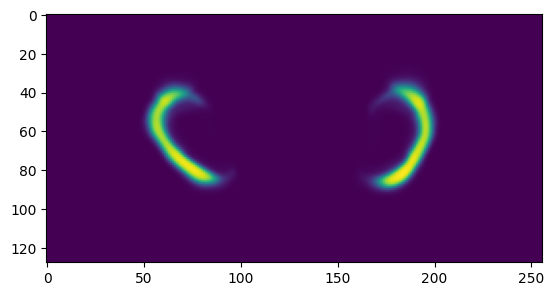

In [19]:
import matplotlib.pyplot as plt
plt.imshow(pred[0,2])

In [20]:
preds = pred_to_map(pred[0], 0, ds)
preds[1].shape

(62808,)

In [21]:
target

{'rater': 'A1', 'subject': 171633}

In [22]:
fmap = imcache.get_flatmap(target, view={'hemisphere': 'rh'})

(-108.28485635169183,
 108.30128402102171,
 -108.28062538581091,
 108.30356904902824)

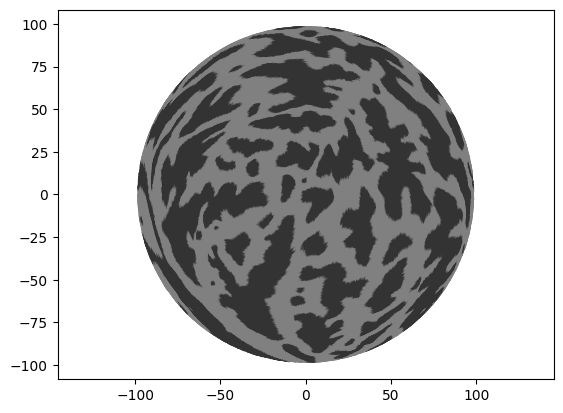

In [23]:
import neuropythy as ny
ny.cortex_plot(fmap)

plt.gca().axis('equal')